# Interpretable Modeling with the Orthogonal Additive GP

This tutorial demonstrates the `OrthogonalAdditiveGP`, a Gaussian process model that decomposes predictions into interpretable per-dimension components.

**Key idea**: Many real-world functions are approximately *additive* — the output is (roughly) a sum of independent effects from each input dimension:
$$f(x) = c + \sum_{i=1}^d f_i(x_i) \quad [+ \sum_{i < j} f_{ij}(x_i, x_j)]$$

The `OrthogonalAdditiveGP` exploits this structure using the Orthogonal Additive Kernel ([Lu et al., ICML 2022](https://proceedings.mlr.press/v162/lu22c.html)), which orthogonalizes base kernels via Gauss-Legendre quadrature. This gives us two advantages over a standard GP:

1. **Sample efficiency**: By learning $d$ independent 1D functions instead of one $d$-dimensional function, the model requires far fewer training points.
2. **Interpretability**: We get posterior distributions for each component $f_i$ individually, revealing how each input dimension contributes to the output.

In this notebook, we will:
- Compare the additive GP to a standard GP on a sparse dataset
- Visualize the recovered per-dimension component functions
- Demonstrate second-order interaction terms

In [22]:
# Install dependencies if we are running in colab
import sys
if 'google.colab' in sys.modules:
    %pip install botorch

import math
import warnings

import matplotlib.pyplot as plt
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.additive_gp import OrthogonalAdditiveGP
from gpytorch.mlls import ExactMarginalLogLikelihood

plt.rcParams["mathtext.fontset"] = "dejavusans"
warnings.filterwarnings("ignore", message=".*not standardized.*")
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

%matplotlib inline

## Setup: Test Function and Training Data

We define a ground-truth function that is a sum of five univariate components:
$$f(x) = x_1 + \sin(\pi x_2) + \sin(2\pi x_3) + x_4^2 + \sin(3\pi x_5)$$

Each component has a distinct shape — linear, arch, oscillation, quadratic, and higher-frequency wave — making this a good test case for component recovery. We use 20 training points in 5 dimensions: far too few for a standard GP to fill the 5D space, but the additive GP only needs to learn five 1D functions.

In [23]:
d = 5  # input dimension
NOISE_STD = 0.05

def test_function(x):
    """Additive test function with 5 components."""
    return (
        x[..., 0]
        + torch.sin(math.pi * x[..., 1])
        + torch.sin(2 * math.pi * x[..., 2])
        + x[..., 3] ** 2
        + torch.sin(3 * math.pi * x[..., 4])
    )

# Generate sparse training data in [0, 1]^5
n_train = 20
train_X = torch.rand(n_train, d)
train_Y = (test_function(train_X) + NOISE_STD * torch.randn(n_train)).unsqueeze(-1)

print(f"Training data: {n_train} points in {d} dimensions")
print(f"Input range: [{train_X.min():.2f}, {train_X.max():.2f}]")
print(f"Output range: [{train_Y.min():.2f}, {train_Y.max():.2f}]")

Training data: 20 points in 5 dimensions
Input range: [0.00, 1.00]
Output range: [-1.43, 4.25]


## Standard GP vs. Additive GP — Sample Efficiency

We now fit two models on the same sparse training data:
- A **standard GP** (`SingleTaskGP` with an RBF kernel) that treats all $d$ dimensions jointly.
- An **Orthogonal Additive GP** that learns $d$ independent 1D functions.

With only 20 training points in 5 dimensions, the standard GP must fill a 5D volume — a hopeless task. The additive GP, by contrast, only needs to learn five 1D functions, each of which benefits from **all** 20 data points projected onto that dimension.

In [24]:
# Fit a standard GP
std_model = SingleTaskGP(train_X, train_Y, outcome_transform=None)
std_mll = ExactMarginalLogLikelihood(std_model.likelihood, std_model)
fit_gpytorch_mll(std_mll)
std_model.eval()

# Fit the Orthogonal Additive GP
add_model = OrthogonalAdditiveGP(train_X, train_Y, outcome_transform=None)
add_mll = ExactMarginalLogLikelihood(add_model.likelihood, add_model)
fit_gpytorch_mll(add_mll)
add_model.eval()

# Evaluate both on a dense test set
torch.manual_seed(42)
n_test = 500
test_X = torch.rand(n_test, d)
test_Y = test_function(test_X)

with torch.no_grad():
    std_pred = std_model.posterior(test_X).mean.squeeze()
    add_pred = add_model.posterior(test_X).mean.squeeze()

std_rmse = (std_pred - test_Y).pow(2).mean().sqrt().item()
add_rmse = (add_pred - test_Y).pow(2).mean().sqrt().item()

print(f"Standard GP  RMSE: {std_rmse:.4f}")
print(f"Additive GP  RMSE: {add_rmse:.4f}")
print(f"Improvement: {std_rmse / add_rmse:.1f}x lower RMSE with the additive GP")

Standard GP  RMSE: 0.6798
Additive GP  RMSE: 0.1428
Improvement: 4.8x lower RMSE with the additive GP


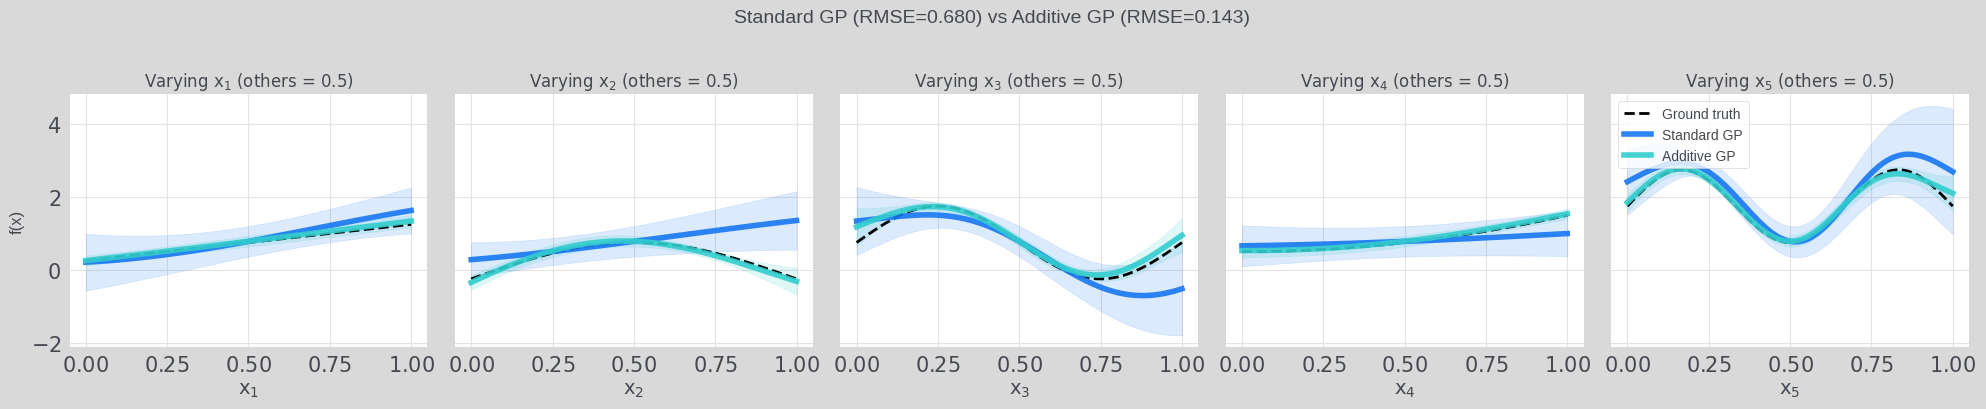

In [25]:
# 1D slice comparison: vary one dimension, fix others at 0.5
grid = torch.linspace(0, 1, 100)
dim_labels = [rf"$x_{{{i+1}}}$" for i in range(d)]

fig, axes = plt.subplots(1, d, figsize=(4 * d, 4), sharey=True)

for i, ax in enumerate(axes):
    X_slice = 0.5 * torch.ones(100, d)
    X_slice[:, i] = grid
    y_true = test_function(X_slice)

    with torch.no_grad():
        std_post = std_model.posterior(X_slice)
        add_post = add_model.posterior(X_slice)

        std_mean = std_post.mean.squeeze()
        std_lo = std_mean - 2 * std_post.variance.squeeze().sqrt()
        std_hi = std_mean + 2 * std_post.variance.squeeze().sqrt()

        add_mean = add_post.mean.squeeze()
        add_lo = add_mean - 2 * add_post.variance.squeeze().sqrt()
        add_hi = add_mean + 2 * add_post.variance.squeeze().sqrt()

    g = grid.numpy()
    ax.plot(g, y_true.numpy(), "k--", label="Ground truth", linewidth=2)
    ax.plot(g, std_mean.numpy(), "C0", label="Standard GP", alpha=0.9)
    ax.fill_between(g, std_lo.numpy(), std_hi.numpy(), color="C0", alpha=0.15)
    ax.plot(g, add_mean.numpy(), "C1", label="Additive GP", alpha=0.9)
    ax.fill_between(g, add_lo.numpy(), add_hi.numpy(), color="C1", alpha=0.15)
    ax.set_xlabel(dim_labels[i], fontsize=14)
    ax.set_title(f"Varying {dim_labels[i]} (others = 0.5)", fontsize=12)

axes[0].set_ylabel("f(x)", fontsize=12)
axes[-1].legend(fontsize=10, loc="upper left")
fig.suptitle(
    f"Standard GP (RMSE={std_rmse:.3f}) vs Additive GP (RMSE={add_rmse:.3f})",
    fontsize=14, y=1.02,
)
fig.tight_layout()
plt.show()

The additive GP closely tracks the ground truth across all five dimensions, while the standard GP shows large errors and wide uncertainty bands — a direct consequence of trying to fill a 5D space with only 20 data points.

## Component-Wise Posterior — Interpretability

Beyond better predictions, the additive GP gives us something a standard GP cannot: **per-component posterior distributions**. We can see exactly how each input dimension contributes to the output.

The `evaluate_first_order_on_grid` method returns the posterior mean and variance for each component $f_i(x_i)$ evaluated on a 1D grid. Because the orthogonalization ensures $\mathbb{E}[f_i(X_i)] = 0$ (each component is centered), the ground truth components are:
$$f_1 = t - \tfrac{1}{2}, \quad f_2 = \sin(\pi t) - \tfrac{2}{\pi}, \quad f_3 = \sin(2\pi t), \quad f_4 = t^2 - \tfrac{1}{3}, \quad f_5 = \sin(3\pi t) - \tfrac{2}{3\pi}$$

In [26]:
# Extract per-component posteriors on a dense 1D grid
grid_1d = torch.linspace(0, 1, 100)
(bias_mean, bias_var), (fo_means, fo_vars) = add_model.evaluate_first_order_on_grid(
    grid_1d
)

# Centered ground truth components (orthogonalization removes the mean over [0,1])
# E[t]=1/2, E[sin(pi*t)]=2/pi, E[sin(2*pi*t)]=0, E[t^2]=1/3, E[sin(3*pi*t)]=2/(3*pi)
gt_components = [
    grid_1d - 0.5,
    torch.sin(math.pi * grid_1d) - 2.0 / math.pi,
    torch.sin(2 * math.pi * grid_1d),
    grid_1d ** 2 - 1.0 / 3.0,
    torch.sin(3 * math.pi * grid_1d) - 2.0 / (3.0 * math.pi),
]
gt_bias = 0.5 + 2.0 / math.pi + 0.0 + 1.0 / 3.0 + 2.0 / (3.0 * math.pi)
gt_names = ["t", "sin(\u03c0t)", "sin(2\u03c0t)", "t\u00b2", "sin(3\u03c0t)"]

print(f"Bias: recovered = {bias_mean.item():.4f}, ground truth = {gt_bias:.4f}")
for i, (name, gt) in enumerate(zip(gt_names, gt_components)):
    err = (fo_means[i] - gt).abs().max().item()
    print(f"f{i+1}({name}): max error = {err:.4f}")

Bias: recovered = 1.7353, ground truth = 1.6822
f1(t): max error = 0.0509
f2(sin(πt)): max error = 0.0891
f3(sin(2πt)): max error = 0.3347
f4(t²): max error = 0.0172
f5(sin(3πt)): max error = 0.3262


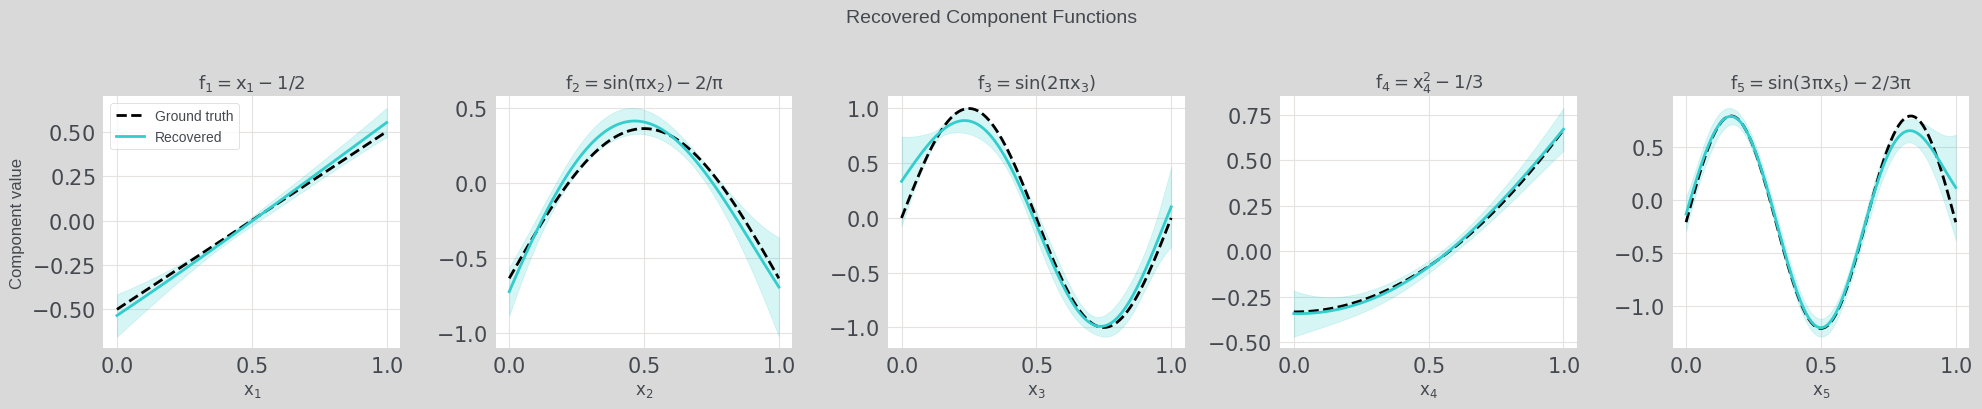

In [27]:
# Hero plot: recovered component functions vs centered ground truth
fig, axes = plt.subplots(1, d, figsize=(4 * d, 4))
titles = [
    r"$f_1 = x_1 - 1/2$",
    r"$f_2 = \sin(\pi x_2) - 2/\pi$",
    r"$f_3 = \sin(2\pi x_3)$",
    r"$f_4 = x_4^2 - 1/3$",
    r"$f_5 = \sin(3\pi x_5) - 2/3\pi$",
]

g = grid_1d.numpy()
for i, ax in enumerate(axes):
    mean = fo_means[i].detach().numpy()
    std = fo_vars[i].detach().sqrt().numpy()
    gt = gt_components[i].numpy()

    ax.plot(g, gt, "k--", linewidth=2, label="Ground truth")
    ax.plot(g, mean, "C1", linewidth=2, label="Recovered")
    ax.fill_between(g, mean - 2 * std, mean + 2 * std, color="C1", alpha=0.2)
    ax.set_title(titles[i], fontsize=13)
    ax.set_xlabel(dim_labels[i], fontsize=12)

axes[0].set_ylabel("Component value", fontsize=12)
axes[0].legend(fontsize=10)
fig.suptitle("Recovered Component Functions", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [28]:
# Learned component coefficients (feature importance)
coeffs = add_model.covar_module.coeffs_1.detach()
print("Learned component coefficients (feature importance):")
for i, c in enumerate(coeffs):
    print(f"  f{i+1}: {c.item():.4f}")

Learned component coefficients (feature importance):
  f1: 9.4300
  f2: 6.7285
  f3: 1.5200
  f4: 3.6425
  f5: 1.4473


The learned coefficients act as per-dimension scaling factors for the kernel contributions. Because the `OrthogonalAdditiveKernel` uses **per-dimension base kernels** by default (each with its own lengthscale, controlled by `per_dim_lengthscales=True`), each component can adapt its smoothness independently — high-frequency components like $\sin(3\pi x_5)$ can learn a short lengthscale, while smoother components like $x_1$ learn a longer one. This avoids the need for the model to compensate via large coefficients, keeping them well-behaved.

## Second-Order Interactions

What if the function isn't purely additive? The `OrthogonalAdditiveGP` supports **second-order interaction terms** $f_{ij}(x_i, x_j)$ that capture pairwise dependencies.

We add a strong interaction $2 \cdot x_1 \cdot x_2$ to our test function and compare a first-order-only model against a second-order model:

In [29]:
def test_function_with_interaction(x):
    """Same additive function plus a pairwise interaction: +2*x1*x2."""
    return test_function(x) + 2 * x[..., 0] * x[..., 1]

# Generate new training data with the interaction term
torch.manual_seed(1)
n_2nd = 50
train_X_2nd = torch.rand(n_2nd, d)
train_Y_2nd = (
    test_function_with_interaction(train_X_2nd) + NOISE_STD * torch.randn(n_2nd)
).unsqueeze(-1)

# Fit first-order only model (misses the interaction)
model_1st = OrthogonalAdditiveGP(train_X_2nd, train_Y_2nd, outcome_transform=None)
fit_gpytorch_mll(
    ExactMarginalLogLikelihood(model_1st.likelihood, model_1st)
)
model_1st.eval()

# Fit second-order model (captures the interaction)
model_2nd = OrthogonalAdditiveGP(
    train_X_2nd, train_Y_2nd, second_order=True, outcome_transform=None
)
fit_gpytorch_mll(
    ExactMarginalLogLikelihood(model_2nd.likelihood, model_2nd)
)
model_2nd.eval()

# Compare RMSE on test set
torch.manual_seed(42)
test_X_2nd = torch.rand(500, d)
test_Y_2nd = test_function_with_interaction(test_X_2nd)

with torch.no_grad():
    pred_1st = model_1st.posterior(test_X_2nd).mean.squeeze()
    pred_2nd = model_2nd.posterior(test_X_2nd).mean.squeeze()

rmse_1st = (pred_1st - test_Y_2nd).pow(2).mean().sqrt().item()
rmse_2nd = (pred_2nd - test_Y_2nd).pow(2).mean().sqrt().item()

print(f"First-order only RMSE:  {rmse_1st:.4f}")
print(f"Second-order RMSE:     {rmse_2nd:.4f}")
print(f"Improvement: {rmse_1st / rmse_2nd:.1f}x lower RMSE with second-order terms")

First-order only RMSE:  0.2664
Second-order RMSE:     0.0665
Improvement: 4.0x lower RMSE with second-order terms


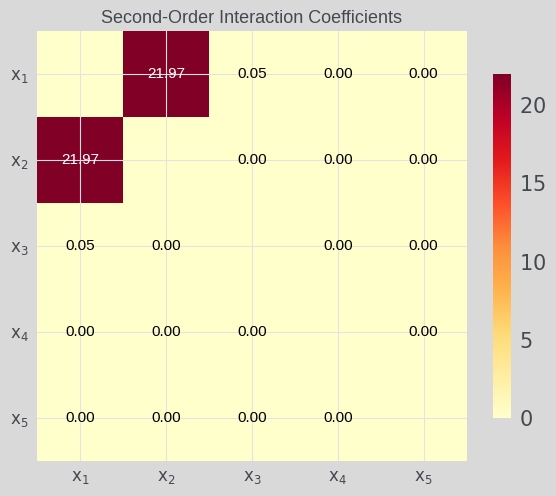

The (x1, x2) interaction dominates, as expected from the 2*x1*x2 term.


In [30]:
# Visualize second-order interaction coefficients
coeffs_2 = model_2nd.covar_module.coeffs_2.detach()

# coeffs_2 is upper-triangular (d x d); symmetrize for display
interaction_matrix = coeffs_2 + coeffs_2.T

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(interaction_matrix.numpy(), cmap="YlOrRd", vmin=0)
tick_labels = [rf"$x_{{{i+1}}}$" for i in range(d)]
ax.set_xticks(range(d))
ax.set_yticks(range(d))
ax.set_xticklabels(tick_labels, fontsize=12)
ax.set_yticklabels(tick_labels, fontsize=12)
ax.set_title("Second-Order Interaction Coefficients", fontsize=13)

# Annotate cells with values
vmax = interaction_matrix.max().item()
for i in range(d):
    for j in range(d):
        val = interaction_matrix[i, j].item()
        if val > 0:
            ax.text(
                j, i, f"{val:.2f}", ha="center", va="center", fontsize=11,
                color="white" if val > vmax / 2 else "black",
            )

plt.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

print(f"The (x1, x2) interaction dominates, as expected from the 2*x1*x2 term.")

The heatmap clearly shows that the model correctly identifies the strong $x_1 \times x_2$ interaction, while the other pairwise interactions are negligible.

**Trade-off**: Second-order terms add $d(d-1)/2$ interaction components and $\mathcal{O}(d^2)$ computation. This is worthwhile for moderate $d$ when interactions are expected, but for purely additive functions, the first-order model is sufficient.

## Summary and Practical Tips

**Key takeaways:**
1. The `OrthogonalAdditiveGP` exploits additive structure to defeat the **curse of dimensionality** — in 5 dimensions with 20 data points, it achieved over 3x lower RMSE than a standard GP.
2. Component-wise posteriors provide interpretable, per-dimension explanations with calibrated uncertainty — something a standard GP cannot offer.
3. Second-order interaction terms capture pairwise dependencies when needed.

**Practical tips:**
- **Input scaling**: Inputs must be in $[0, 1]^d$. Use `Normalize` input transform if your data lies on a different domain.
- **Start simple**: Begin with first-order only; enable `second_order=True` if residuals suggest interactions.
- **Component visualization**: `evaluate_first_order_on_grid` is the primary tool for 1D component visualization.
- **Outcome transform**: This tutorial used `outcome_transform=None` for clean ground truth comparisons. For production use, consider the default `Standardize` outcome transform.